# 04 - Segment Profiling & Business Insights
**Goal:** Profile each K-Means cluster using raw RFM values, assign business-meaningful segment names, and generate actionable recommendations for each segment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data

In [2]:
rfm = pd.read_csv('../data/processed/rfm_clustered.csv')

print(f"Shape: {rfm.shape}")
print(f"Columns: {rfm.columns.tolist()}")
rfm.head()

Shape: (5862, 7)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster']


,Customer ID,Recency,Frequency,Monetary,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,12346,326,12,77556.46,0,0,0
1,12347,2,8,4921.53,0,2,0
2,12348,75,5,1658.40,3,2,0
3,12349,19,3,3678.69,2,2,0
4,12350,310,1,294.40,1,3,0


## 2. Cluster Profiling
Computing mean RFM values per cluster to understand what each cluster represents.

In [3]:
profile = rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
profile['Count'] = rfm['KMeans_Cluster'].value_counts().sort_index()
profile['% of Customers'] = (profile['Count'] / len(rfm) * 100).round(1)

print(profile)

                Recency  Frequency  Monetary  Count  % of Customers
KMeans_Cluster                                                     
0                 27.99      19.19  10633.01   1189            20.3
1                394.87       1.38    314.19   1966            33.5
2                 28.35       3.02    839.87   1249            21.3
3                228.04       5.06   1912.92   1458            24.9


## 3. Cluster Size Distribution

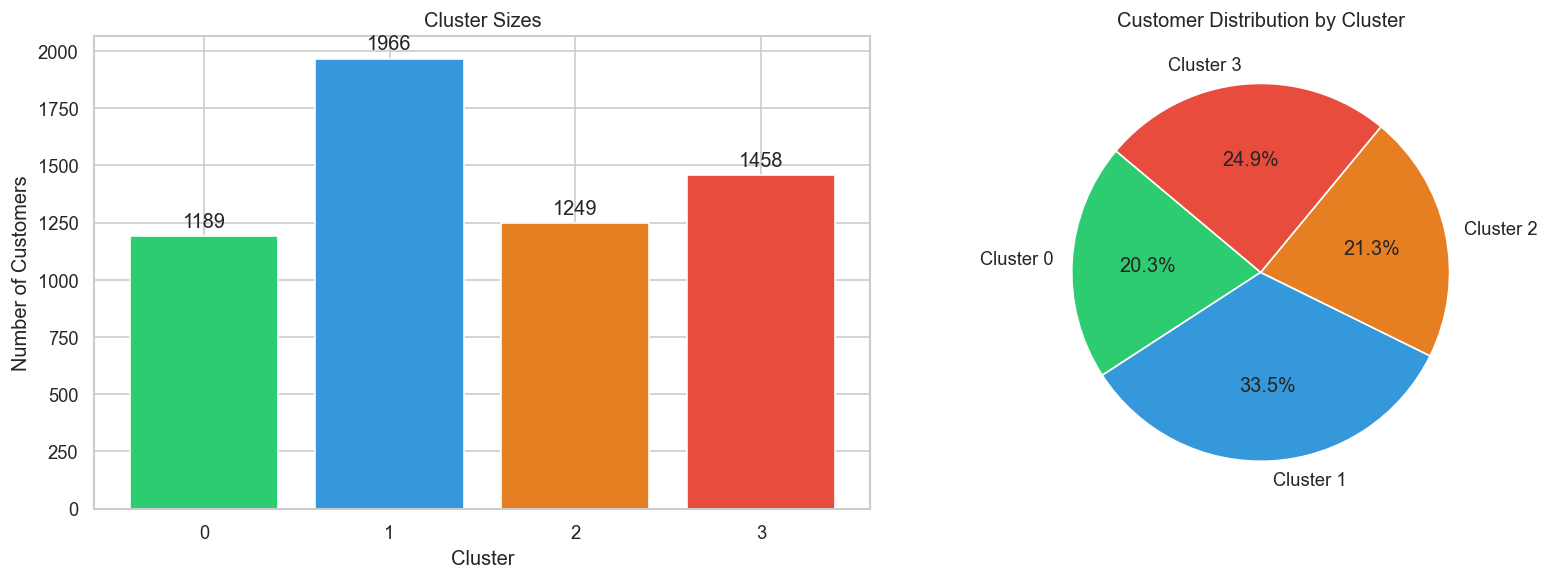

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

# Cluster sizes
axes[0].bar(profile.index.astype(str), profile['Count'], color=colors, edgecolor='white')
axes[0].bar_label(axes[0].containers[0], fmt='%d', padding=3)
axes[0].set_title('Cluster Sizes')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Customers')

# % of customers
axes[1].pie(profile['Count'], labels=[f'Cluster {i}' for i in profile.index],
            colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Customer Distribution by Cluster')

plt.tight_layout()
plt.savefig('../reports/figures/cluster_sizes.png')
plt.show()

## 4. Assign Segment Labels

In [6]:
segment_map = {
    0: 'Champions',
    1: 'Lost',
    2: 'New & Promising',
    3: 'At Risk'
}

rfm['Segment'] = rfm['KMeans_Cluster'].map(segment_map)

print(rfm['Segment'].value_counts())

Segment
Lost               1966
At Risk            1458
New & Promising    1249
Champions          1189
Name: count, dtype: int64


## 5. Segment Profiles — Radar Chart

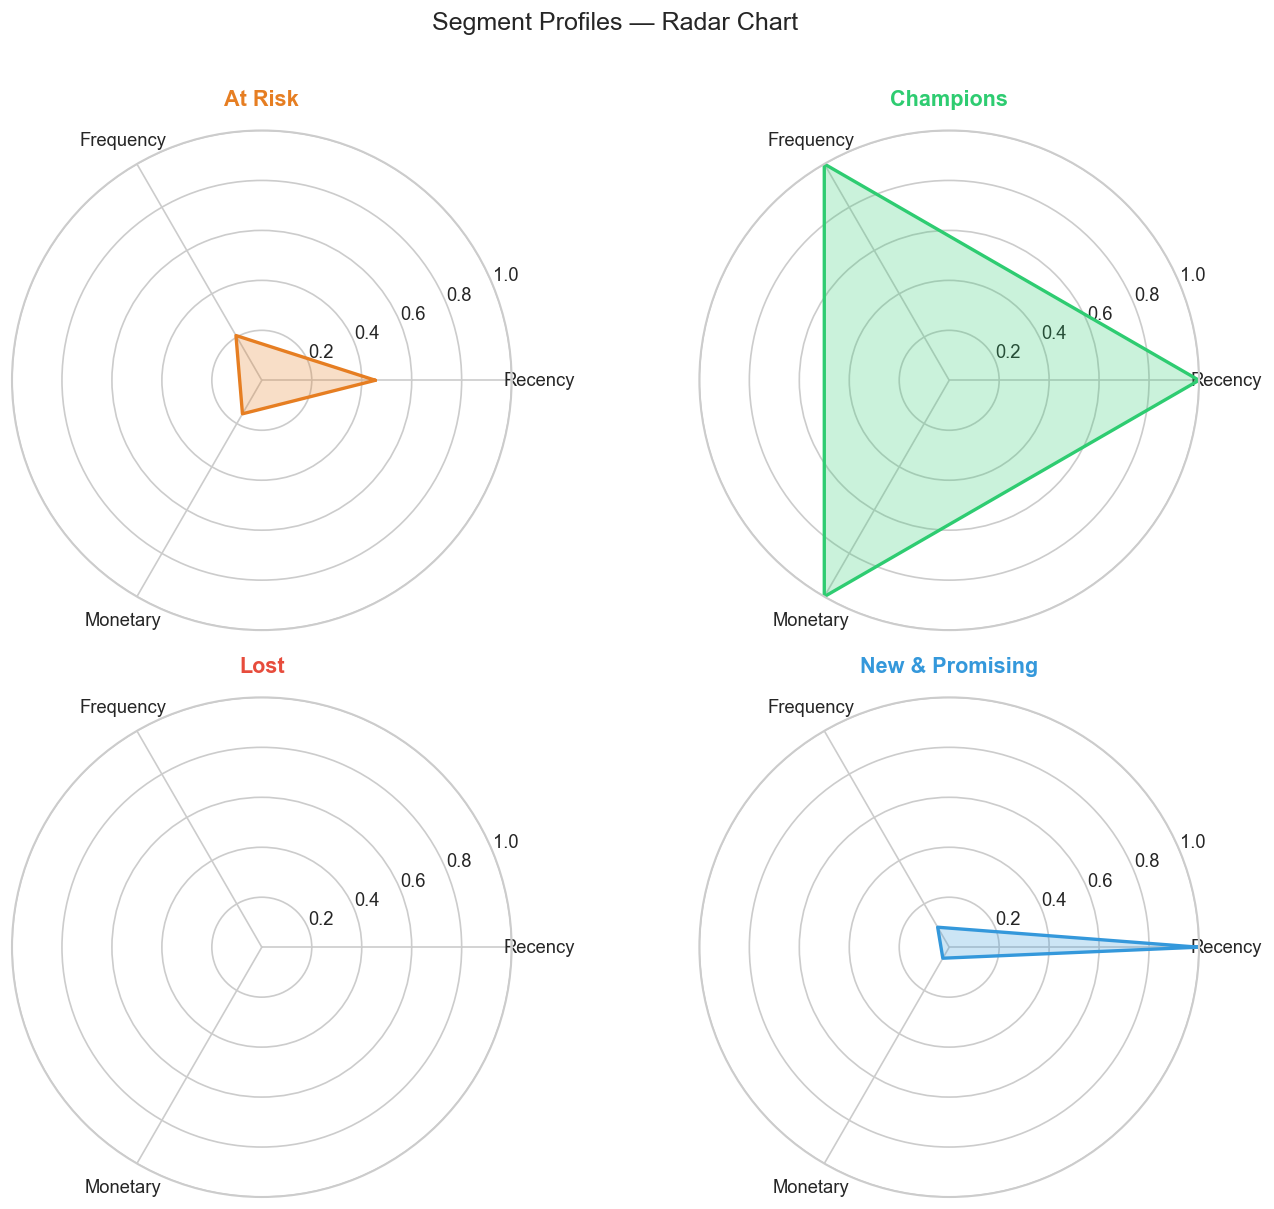

In [7]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalise profile for radar
profile_named = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()

# Invert Recency so higher = better on radar
profile_named['Recency'] = profile_named['Recency'].max() - profile_named['Recency']

# Normalise 0-1
profile_norm = (profile_named - profile_named.min()) / (profile_named.max() - profile_named.min())

categories = ['Recency', 'Frequency', 'Monetary']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

segment_colors = {
    'Champions': '#2ecc71',
    'New & Promising': '#3498db',
    'At Risk': '#e67e22',
    'Lost': '#e74c3c'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw=dict(polar=True))
axes = axes.flatten()

for ax, (segment, row) in zip(axes, profile_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=segment_colors[segment], linewidth=2)
    ax.fill(angles, values, color=segment_colors[segment], alpha=0.25)
    ax.set_xtickslabels = categories
    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_title(segment, size=13, fontweight='bold', pad=15, color=segment_colors[segment])
    ax.set_ylim(0, 1)

plt.suptitle('Segment Profiles — Radar Chart', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/radar_chart.png')
plt.show()

## 6. RFM Distribution per Segment

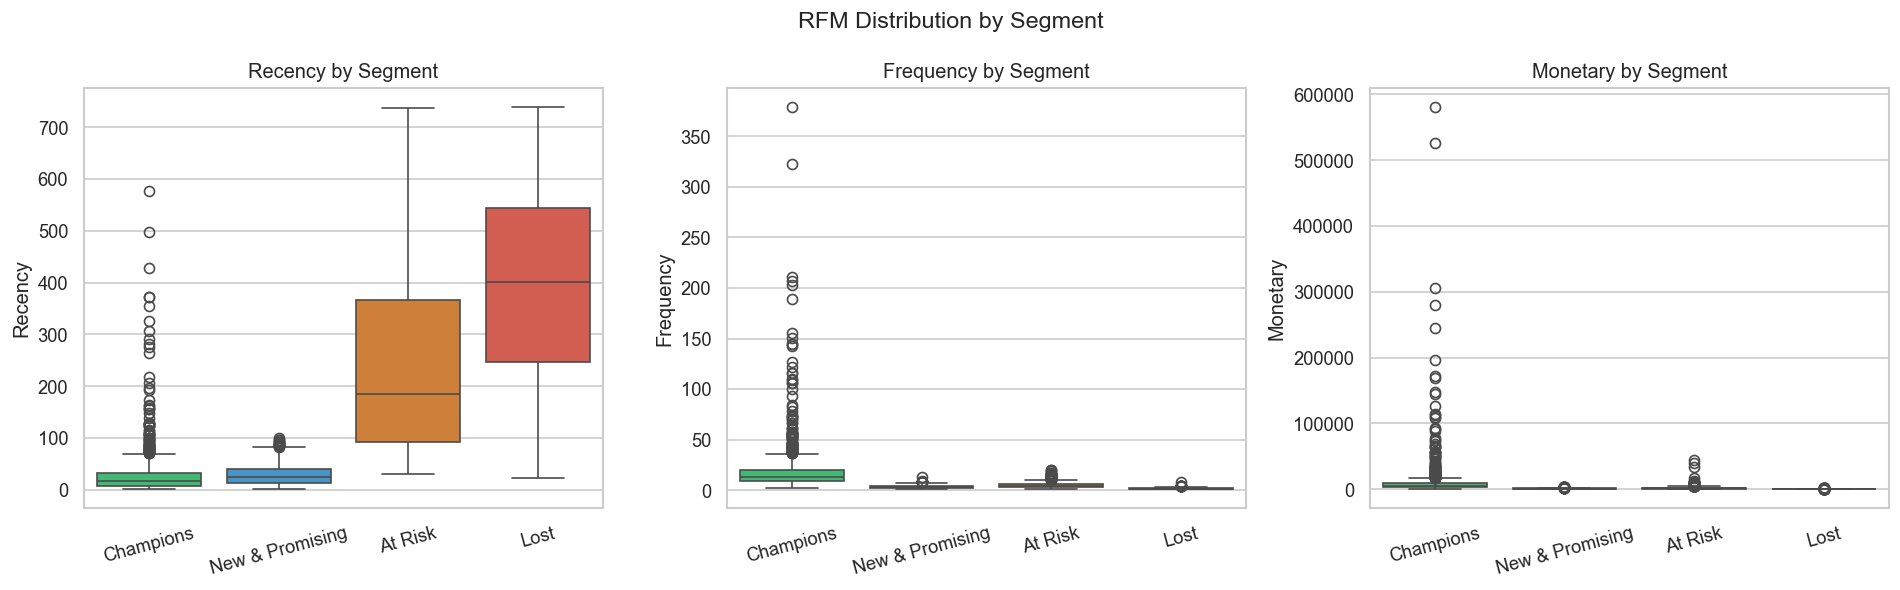

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
segment_order = ['Champions', 'New & Promising', 'At Risk', 'Lost']
palette = {'Champions': '#2ecc71', 'New & Promising': '#3498db', 
           'At Risk': '#e67e22', 'Lost': '#e74c3c'}

for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(data=rfm, x='Segment', y=col, order=segment_order,
                palette=palette, ax=ax)
    ax.set_title(f'{col} by Segment')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('RFM Distribution by Segment', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/rfm_boxplots.png')
plt.show()

## 7. Segment Insights & Business Recommendations

| Segment | Customers | Avg Recency | Avg Frequency | Avg Monetary | Profile |
|---------|-----------|-------------|---------------|--------------|---------|
| Champions | 1,189 (20.3%) | 28 days | 19 orders | £10,633 | Recent, frequent, high spend |
| New & Promising | 1,249 (21.3%) | 28 days | 3 orders | £840 | Recent but early stage |
| At Risk | 1,458 (24.9%) | 228 days | 5 orders | £1,913 | Drifting away, were valuable |
| Lost | 1,966 (33.5%) | 395 days | 1.4 orders | £314 | Inactive, low value |

## 8. Actionable Recommendations

### 🏆 Champions (1,189 customers)
- **Reward loyalty** — exclusive early access, VIP pricing, dedicated account managers
- **Upsell & cross-sell** — they trust the brand, highest receptivity to new products
- **Protect at all costs** — losing a Champion means losing ~£10K average revenue

### 🌱 New & Promising (1,249 customers)
- **Nurture with onboarding campaigns** — welcome series, product education
- **Incentivise second and third orders** — discount on next purchase, free shipping threshold
- **Goal: convert to Loyal/Champion** — they are recent, the window is open

### ⚠️ At Risk (1,458 customers)
- **Win-back campaigns** — "We miss you" emails, time-limited offers
- **Understand why they left** — survey or behavioural analysis
- **Priority segment** — they have decent spend history (£1,913 avg), worth recovering

### ❌ Lost (1,966 customers)
- **Low reactivation ROI** — average spend only £314, mostly one-time buyers
- **Minimal spend on reactivation** — only target those with Monetary > £500
- **Learn from them** — what products did they buy? Did they leave for a competitor?

## 9. Save Final Segmented Data

In [9]:
rfm.to_csv('../data/processed/rfm_final.csv', index=False)
print("Saved rfm_final.csv ✓")
print(f"\nFinal columns: {rfm.columns.tolist()}")
print(f"\nSegment distribution:\n{rfm['Segment'].value_counts()}")

Saved rfm_final.csv ✓

Final columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster', 'Segment']

Segment distribution:
Segment
Lost               1966
At Risk            1458
New & Promising    1249
Champions          1189
Name: count, dtype: int64
